In [1]:
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from statsmodels.stats.anova import AnovaRM

from multipred.plotting import (barplot_morey, plot_learning_interaction, pointplot_morey)

In [2]:
PROJECT_PATH = "/media/wiseman/tocho/multipred-fmri"
DATA_PATH = f"{PROJECT_PATH}/data/derivatives/decoding_data"
ROI = "EVC"
N_VOXELS = "wholeROI"

# Loading balanced data

In [3]:
# Balanced data will be used for most of the analyses
balanced_df = pd.read_csv(f"{DATA_PATH}/{ROI}_{N_VOXELS}/balanced_group_data.csv") 
            
balanced_df["correct"] = balanced_df["correct"].astype(int)
balanced_df["pred"] = balanced_df["pred"].astype(str)
balanced_df["ign_pred"] = balanced_df["ign_pred"].astype(str)
balanced_df["v_pred"] = np.where(balanced_df["modality"] == "visual", balanced_df["pred"], balanced_df["ign_pred"])
balanced_df["a_pred"] = np.where(balanced_df["modality"] == "auditory", balanced_df["pred"], balanced_df["ign_pred"])
balanced_df["v_learned"] = balanced_df["v_learned"].astype(str)
balanced_df["a_learned"] = balanced_df["a_learned"].astype(str)
balanced_df["expected_stim"] = np.where(balanced_df["expected_stim"] == 0, "CW", "CCW")
balanced_df["stim"] = np.where(balanced_df["stim"] == 0, "CW", "CCW")

balanced_df["z_distance_abs"] = np.abs(balanced_df["z_distance"])

balanced_df["v_learned"] = balanced_df["v_learned"].astype("category")
balanced_df["expected_stim"] = balanced_df["expected_stim"].astype("category")


# Loading and aggregating data from all trials across permutations

In [4]:
# The dataframe with all trials will be used to fit regression models with trial by trial measures
# The reason for this is that before fitting we need to aggreggate the data of each trial across permutations
# This can't be done with the balanced data, as it requires to have different sets of trials at each permutation
alltrials_df = pd.read_csv(f"{DATA_PATH}/{ROI}_{N_VOXELS}/group_data.csv") 
            
alltrials_df["correct"] = alltrials_df["correct"].astype(int)
alltrials_df["pred"] = alltrials_df["pred"].astype(str)
alltrials_df["ign_pred"] = alltrials_df["ign_pred"].astype(str)
alltrials_df["v_pred"] = np.where(alltrials_df["modality"] == "visual", alltrials_df["pred"], alltrials_df["ign_pred"])
alltrials_df["a_pred"] = np.where(alltrials_df["modality"] == "auditory", alltrials_df["pred"], alltrials_df["ign_pred"])
alltrials_df["v_learned"] = alltrials_df["v_learned"].astype(str)
alltrials_df["a_learned"] = alltrials_df["a_learned"].astype(str)
alltrials_df["expected_stim"] = np.where(alltrials_df["expected_stim"] == 0, "CW", "CCW")
alltrials_df["stim"] = np.where(alltrials_df["stim"] == 0, "CW", "CCW")

# Aggregate across perms, while retaining important columns
alltrials_df = alltrials_df.groupby(['subj', 'run', 'trial']).agg(
    correct=('correct', 'mean'), 
    modality=('modality', 'first'),
    v_pred=('v_pred', 'first'),
    a_pred=('a_pred', 'first'),
    v_learned=('v_learned', 'first'),
    a_learned=('a_learned', 'first'),
    classified_stim=('classified_stim', 'mean'),
    stim = ('stim', 'first'),
    expected_stim=('expected_stim', 'first'),
    z_distance=('z_distance', 'mean'),
    decision_distances=('decision_distances', 'mean'),
    prob_0=('prob_0', 'mean'),
    prob_1=('prob_1', 'mean'),
).reset_index()

# Binarize the 'correct' column
alltrials_df['correct'] = alltrials_df['correct'].round()


# Defining factors for pymer4 
v_pred = {"v_pred" : ["0", "1"]}
a_pred = {"a_pred" : ["0", "1"]}
v_learned = {"v_learned" : ["0", "1"]}
a_learned = {"a_learned" : ["0", "1"]}
expected_stim = {"expected_stim" : ["CW", "CCW"]}


### Visual attended

### Triple interaction

/media/wiseman/tocho/multipred-fmri/multipred/plotting.py:357: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat['subject_mean'] = dat.groupby(id_col)[y].transform('mean')
/media/wiseman/tocho/multipred-fmri/multipred/plotting.py:358: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat['cousineau_normalized'] = dat[y] - dat['subject_mean']
/media/wiseman/tocho/multipred-fmri/multipred/plotting.py:360: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[ro

                         Anova
                          F Value Num DF  Den DF Pr > F
-------------------------------------------------------
stim                      14.9090 1.0000 24.0000 0.0007
expected_stim              1.7473 1.0000 24.0000 0.1987
a_pred                     0.7342 1.0000 24.0000 0.4000
stim:expected_stim         0.6399 1.0000 24.0000 0.4316
stim:a_pred                2.4252 1.0000 24.0000 0.1325
expected_stim:a_pred       5.5774 1.0000 24.0000 0.0266
stim:expected_stim:a_pred  1.2952 1.0000 24.0000 0.2663



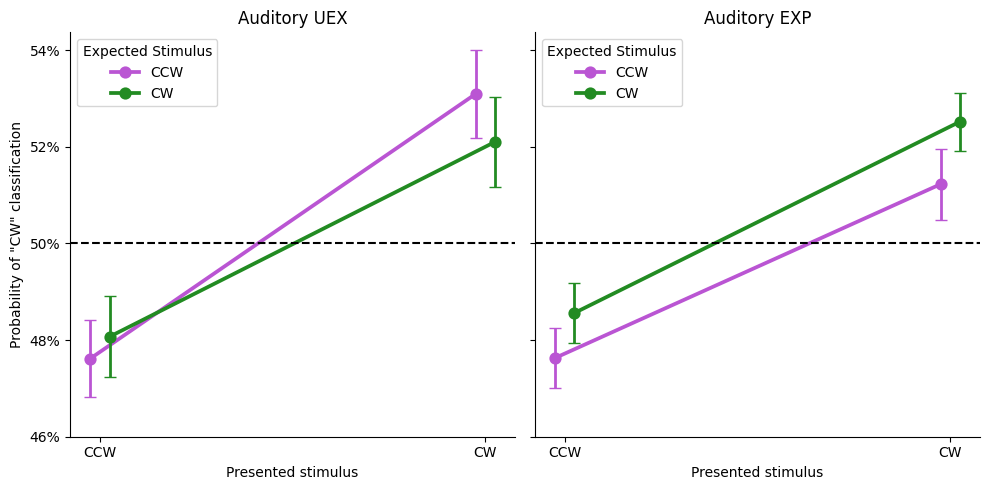

In [5]:
x="stim" # Presented CW or
hue="expected_stim" # expected CW or CCW
col="a_pred" # auditory EXP or UEX
y="prob_1" # probability of choosing CW
id="subj" # subject id

data=balanced_df.copy()
dat = data[data["modality"] == "visual"].copy().groupby(
    [id, hue, x, col]
)[y].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
# plot x axis in order CCW, CW
# Loop through unique col levels
for i, col_level in enumerate(dat[col].unique()):
    pointplot_morey(dat[dat[col] == col_level], x, y, hue, id_col=id, swarmplot_plot=False, palette=["mediumorchid", "forestgreen"], dodge_width=0.05, hline = 0.5, ax=axes[i])
    exp_label="UEX" if col_level=="0" else "EXP"
    axes[i].set_title(f"Auditory {exp_label}")
    axes[i].legend().set_title("Expected Stimulus")
    axes[i].set_xlabel("Presented stimulus")
    axes[i].set_xticklabels(["CCW", "CW"])
    axes[i].set_ylabel(f'Probability of "CW" classification')
    axes[i].set_yticks(np.linspace(0.46, .54, 5))
    # Format y-axis as percentage rounded
    axes[i].yaxis.set_major_formatter(mtick.PercentFormatter(1, decimals=0))

# Run the three-way repeated measures ANOVA
aov = AnovaRM(data=dat, 
              depvar=y, #"classified_stim",  # Dependent Variable
              subject=id,             # Subject ID (repeated measures)
              within=[x, hue, col])  # Within-subject factors

result = aov.fit()
print(result)

plt.tight_layout()
plt.show()


/tmp/ipykernel_76467/3294053945.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels([f"{tick*100:.0f}%" for tick in original_ticks]) # Set new labels formatted as percentages


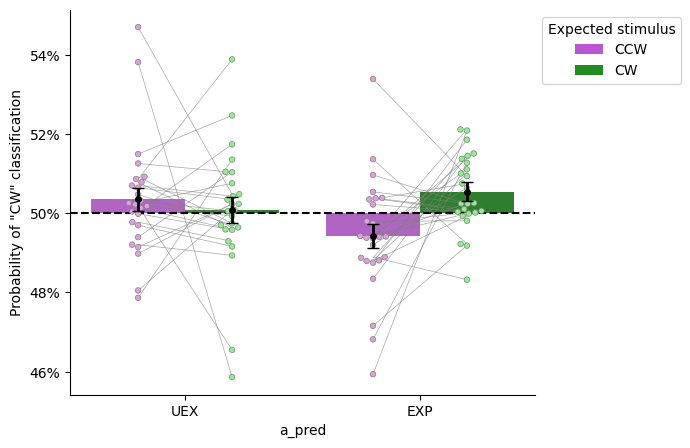

                      Anova
                     F Value Num DF  Den DF Pr > F
--------------------------------------------------
a_pred                0.7342 1.0000 24.0000 0.4000
expected_stim         1.7473 1.0000 24.0000 0.1987
a_pred:expected_stim  5.5774 1.0000 24.0000 0.0266

TtestResult(statistic=np.float64(-0.5768439596020317), pvalue=np.float64(0.5694165216688774), df=np.int64(24))
TtestResult(statistic=np.float64(2.8315764897349602), pvalue=np.float64(0.009225715156879285), df=np.int64(24))


In [36]:
x="a_pred" # auditory EXP or UEX
hue="expected_stim" # expected CW or CCW
y="centered_prob" # probability of choosing CW
id="subj" # subject id
data=balanced_df.copy()
data["centered_prob"] = data["prob_1"] - 0.5

# Direct comparisons between expected stimuli ( without taking into account the presented stimulus)
dat = data[(data["modality"] == "visual")].copy().groupby(
    [id, hue, x]
)[y].mean().reset_index()


palette1 = ["mediumorchid", "forestgreen"]
palette2 = ["plum", "lightgreen"]

fig, ax = plt.subplots(1, 1, figsize=(6, 5))

barplot_morey(dat, x, y, hue, "Expected stimulus", palette1, palette2, True, True, True, ax)
ax.set_xticks([0, 1], ["UEX", "EXP"])
ax.set_ylabel(f'Probability of "CW" classification') #plt.ylabel(f"probability of classifying CCW")

# Get the current y-tick values (which are in centered probability space)
y_ticks = plt.gca().get_yticks()
original_ticks = [tick + 0.5 for tick in y_ticks] # convert to original probability space
plt.gca().set_yticklabels([f"{tick*100:.0f}%" for tick in original_ticks]) # Set new labels formatted as percentages

plt.axhline(0, color='black', linestyle='--')
sns.despine()
plt.show()

# two-way repeated measures ANOVA
aov = AnovaRM(data=dat, 
              depvar=y, #"classified_stim",  # Dependent Variable
              subject=id,             # Subject ID (repeated measures)
              within=[x, hue])  # Within-subject factors

result = aov.fit()
print(result)

for a_pred in dat["a_pred"].unique():
    a = dat[(dat["a_pred"]==a_pred) & (dat["expected_stim"]=="CW")].groupby("subj")[y].mean()
    b = dat[(dat["a_pred"]==a_pred) & (dat["expected_stim"]=="CCW")].groupby("subj")[y].mean()
    print(stats.ttest_rel(a, b))

### LMMs to assess effect of trial by trial explicit knowledge 

(if prediction was explictly recalled in the final explicit test by the participant or not)

In [17]:
alltrials_df["expected_stim"] = alltrials_df["expected_stim"].astype("category")
alltrials_df["stim"] = alltrials_df["stim"].astype("category")
alltrials_df["v_learned"] = alltrials_df["v_learned"].astype("category")
alltrials_df["a_learned"] = alltrials_df["a_learned"].astype("category")
alltrials_df["a_pred"] = alltrials_df["a_pred"].astype("category")

In [ ]:
dat = alltrials_df[(alltrials_df["modality"]=="visual") & (alltrials_df["a_pred"]=="1")].copy()
md = sm.MixedLM.from_formula("prob_1 ~ stim + expected_stim * v_learned", data=dat, groups=dat["subj"])
mdf = md.fit()
print(mdf.summary())

                    Mixed Linear Model Regression Results
Model:                     MixedLM        Dependent Variable:        prob_1   
No. Observations:          3600           Method:                    REML     
No. Groups:                25             Scale:                     0.0082   
Min. group size:           144            Log-Likelihood:            3524.1968
Max. group size:           144            Converged:                 Yes      
Mean group size:           144.0                                              
------------------------------------------------------------------------------
                                   Coef.  Std.Err.    z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------
Intercept                           0.482    0.003 158.223 0.000  0.476  0.488
stim[T.CW]                          0.038    0.004   9.361 0.000  0.030  0.046
expected_stim[T.CW]                 0.001    0.005   0.142 0.887 -0.009  

/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


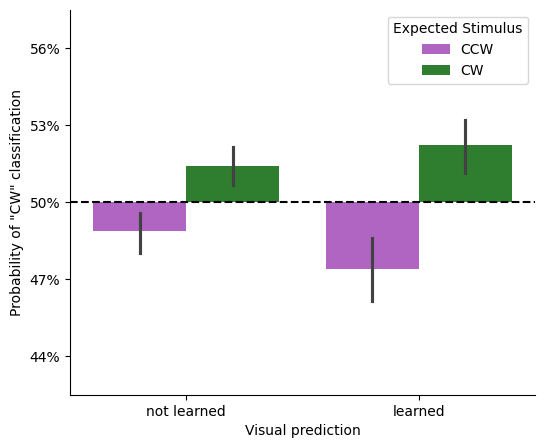

In [20]:
x = "v_learned"
hue = "expected_stim"

# Create a new column with the centered probability
dat["centered_prob"] = dat["prob_1"] - 0.5
y = "centered_prob"
dat = dat.groupby([hue, x, id])[y].mean().reset_index()
palette = ["mediumorchid", "forestgreen"]

# Create figure and axis
fig, ax = plt.subplots(figsize=(6, 5))

# Call function with ax
plot_learning_interaction(dat, x, y, hue, "CW", palette, 0, ax)

# Show the plot
plt.show()

In [ ]:
# Check only for auditory expected trials
# Did it first using pymer4 but it relies on R, making for a more complicated setup
# model = Lmer("prob_1 ~ stim + expected_stim * v_learned + (1|subj)", data=alltrials_df[(alltrials_df["modality"]=="visual") & (alltrials_df["a_pred"]=="1")])
# model.fit()

Linear mixed model fit by REML [’lmerMod’]
Formula: prob_1~stim+expected_stim*v_learned+(1|subj)

Family: gaussian	 Inference: parametric

Number of observations: 3600	 Groups: {'subj': 25.0}

Log-likelihood: 3524.197 	 AIC: -7034.394

Random effects:

                 Name    Var    Std
subj      (Intercept)  0.000  0.002
Residual               0.008  0.090

No random effect correlations specified

Fixed effects:



,Estimate,2.5_ci,97.5_ci,SE,DF,T-stat,P-val,Sig
(Intercept),0.482,0.477,0.488,0.003,77.147,166.935,0.000,***
stimCW,0.038,0.030,0.046,0.004,3565.117,9.361,0.000,***
expected_stimCW,0.001,-0.009,0.010,0.005,1383.296,0.147,0.883,
v_learned1,-0.016,-0.025,-0.007,0.004,75.611,-3.598,0.001,***
expected_stimCW:v_learned1,0.024,0.012,0.037,0.006,191.238,3.966,0.000,***


In [ ]:
dat = alltrials_df[(alltrials_df["modality"]=="visual")].copy()
md = sm.MixedLM.from_formula("prob_1 ~ stim + expected_stim * v_learned * a_pred", data=dat, groups=dat["subj"])
mdf = md.fit()
print(mdf.summary())

                          Mixed Linear Model Regression Results
Model:                        MixedLM            Dependent Variable:            prob_1   
No. Observations:             4800               Method:                        REML     
No. Groups:                   25                 Scale:                         0.0082   
Min. group size:              192                Log-Likelihood:                4687.0085
Max. group size:              192                Converged:                     Yes      
Mean group size:              192.0                                                      
-----------------------------------------------------------------------------------------
                                               Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------------------
Intercept                                       0.480    0.005 93.703 0.000  0.470  0.490
stim[T.CW]                          

/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


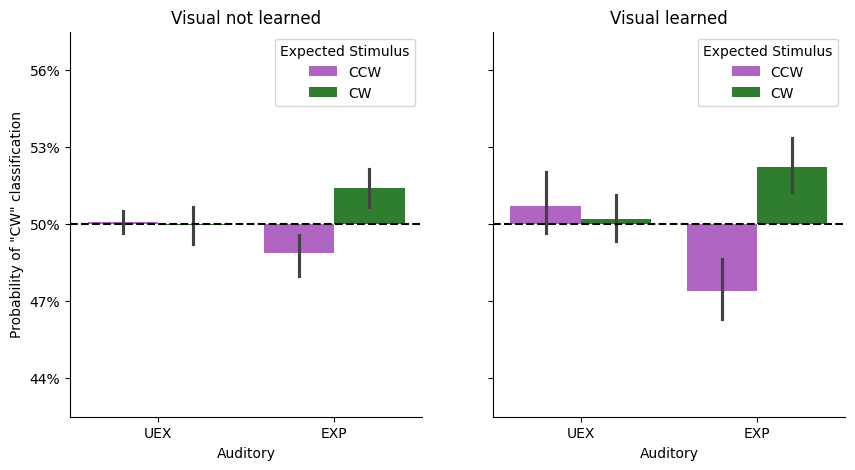

In [22]:
y = "centered_prob"
x = "a_pred"
hue = "expected_stim"
id = "subj"
col = "v_learned"

# Create a new column with the centered probability
dat["centered_prob"] = dat["prob_1"] - 0.5
# Direct comparisons between expected stimuli ( without taking into account the presented stimulus)
dat = dat.groupby([id, hue, x, col])[y].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
for i, col_level in enumerate(np.sort(dat[col].unique())):
    plot_learning_interaction(dat[dat[col] == col_level], x, y, hue, "CW", palette, 0, axes[i])
    col_label = "not learned" if col_level == "0" else "learned"
    axes[i].set_title(f"Visual {col_label}")

In [ ]:
# # Check triple interaction with auditory expectation
# model = Lmer("prob_1 ~ stim + expected_stim * v_learned * a_pred + (1|subj)", data=alltrials_df[(alltrials_df["modality"]=="visual")])
# model.fit()


boundary (singular) fit: see help('isSingular') 

Linear mixed model fit by REML [’lmerMod’]
Formula: prob_1~stim+expected_stim*v_learned*a_pred+(1|subj)

Family: gaussian	 Inference: parametric

Number of observations: 4800	 Groups: {'subj': 25.0}

Log-likelihood: 4687.009 	 AIC: -9352.017

Random effects:

                 Name    Var   Std
subj      (Intercept)  0.000  0.00
Residual               0.008  0.09

No random effect correlations specified

Fixed effects:



,Estimate,2.5_ci,97.5_ci,SE,DF,T-stat,P-val,Sig
(Intercept),0.480,0.471,0.490,0.005,4791.0,95.551,0.000,***
stimCW,0.041,0.035,0.048,0.003,4791.0,12.968,0.000,***
expected_stimCW,-0.001,-0.015,0.012,0.007,4791.0,-0.196,0.844,
v_learned1,0.006,-0.009,0.021,0.008,4791.0,0.816,0.414,
a_pred1,0.001,-0.010,0.012,0.006,4791.0,0.194,0.846,
expected_stimCW:v_learned1,-0.004,-0.024,0.017,0.011,4791.0,-0.360,0.719,
expected_stimCW:a_pred1,-0.000,-0.016,0.016,0.008,4791.0,-0.000,1.000,
v_learned1:a_pred1,-0.021,-0.039,-0.004,0.009,4791.0,-2.470,0.014,*
expected_stimCW:v_learned1:a_pred1,0.027,0.004,0.051,0.012,4791.0,2.253,0.024,*
